# 01a - Full 18-target neural RDM with common-reference preprocessing

This standalone notebook asks whether Sets A, B, and C form visible blocks in a common neural representational dissimilarity matrix (RDM). It replaces the exploratory 18-target appendices that previously appeared in Notebooks 02 and 03.

The goal is **not** to manufacture darker within-set blocks. The previous within-run z-scoring forced each set's six target centroids to balance around zero, producing within-set correlation distances near $1.2$ by construction. Here every pipeline preserves a common coordinate system across A, B, and C.

The analysis remains exploratory because stimulus set and acquisition run are confounded. A positive between-minus-within contrast can reflect stimulus organization, stable run differences, or both.

In [1]:
from pathlib import Path
import sys

REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / 'nsdimagery').is_dir():
    REPO_ROOT = REPO_ROOT.parent
if not (REPO_ROOT / 'nsdimagery').is_dir():
    raise RuntimeError('Start Jupyter from the repository root or its notebooks/ directory.')
sys.path.insert(0, str(REPO_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

from nsdimagery import (
    build_event_table, build_run_table, correlation_rdm,
    crossvalidated_dot_rdm, extract_masked_betas, find_data_root,
    load_roi, paths_for_subject, zscore_within_groups,
)

sns.set_theme(style='whitegrid', context='notebook')
DATA_ROOT = find_data_root(REPO_ROOT)
print('Python:', sys.version.split()[0])
print('Repository:', REPO_ROOT)
print('Data root:', DATA_ROOT)

Python: 3.12.13
Repository: /home/jovyan/NHprojectNSDimagery
Data root: /home/jovyan/NHprojectNSDimagery/data/nsd


## 1. Configuration

The analysis uses the same subjects, ROI definitions, voxel cap, and deterministic voxel samples as Notebook 03. It reuses that notebook's beta cache when available. Subject 01 remains the pilot display; group summaries use held-out subjects 02-08.

In [2]:
SUBJECTS = tuple(range(1, 9))
PILOT_SUBJECT = 1
HELDOUT_SUBJECTS = tuple(subject for subject in SUBJECTS if subject != PILOT_SUBJECT)
TASK_ORDER = ('vision', 'imagery')
SET_ORDER = ('A', 'B', 'C')
PIPELINE_ORDER = ('raw_glmsingle', 'task_pooled', 'attention_reference')
PRIMARY_PIPELINE = 'attention_reference'

ROI_SPECS = {
    'nsdgeneral': {'mask_name': 'nsdgeneral', 'labels': None},
    'early_visual': {'mask_name': 'prf-visualrois', 'labels': tuple(range(1, 7))},
    'higher_visual': {'mask_name': 'streams', 'labels': (5, 6, 7)},
}
ROI_ORDER = tuple(ROI_SPECS)
MAX_VOXELS_PER_ROI = 1200
BASE_SEED = 2026

OUTPUT_DIR = REPO_ROOT / 'outputs' / '01a_full18_rdm'
CACHE_DIR = DATA_ROOT / 'derived' / 'notebook03_beta_cache'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)

print('Subjects:', SUBJECTS)
print('Held out:', HELDOUT_SUBJECTS)
print('ROIs:', ROI_ORDER)
print('Primary pipeline:', PRIMARY_PIPELINE)
print('Voxel cap:', MAX_VOXELS_PER_ROI)

Subjects: (1, 2, 3, 4, 5, 6, 7, 8)
Held out: (2, 3, 4, 5, 6, 7, 8)
ROIs: ('nsdgeneral', 'early_visual', 'higher_visual')
Primary pipeline: attention_reference
Voxel cap: 1200


## 2. Preprocessing routes

All routes begin with the released GLMsingle beta estimates and average repetitions only after preprocessing.

1. **Raw GLMsingle:** no additional centering or scaling. This is a sensitivity analysis for run offsets and heterogeneous voxel scales.
2. **Task-pooled:** for each voxel, vision trials are standardized together across all 18 targets, and imagery trials are standardized together across all 18 targets. This removes the set-specific zero-sum constraint.
3. **Attention reference (primary):** one voxel mean and standard deviation are estimated from all 288 released attention beta events pooled across Sets A, B, and C. The same independently estimated transform is then applied to every vision and imagery trial.

The attention data are used only as an unlabeled normalization reference. No attention target labels enter the RDM. The resulting transform is common across stimulus sets and tasks.

In [3]:
def cache_path(subject, roi_name, seed):
    voxel_token = 'all' if MAX_VOXELS_PER_ROI is None else str(MAX_VOXELS_PER_ROI)
    return CACHE_DIR / f'subj{subject:02d}_{roi_name}_n{voxel_token}_seed{seed}.npz'


def load_or_extract_roi_betas(subject, roi_name, roi_index):
    spec = ROI_SPECS[roi_name]
    seed = BASE_SEED + subject * 100 + roi_index
    path = cache_path(subject, roi_name, seed)
    if path.is_file():
        with np.load(path) as cached:
            betas = cached['betas']
            coordinates = cached['coordinates']
        print(f'  {roi_name}: cache hit, {betas.shape[1]} voxels')
        return betas, coordinates

    mask, _ = load_roi(DATA_ROOT, subject, spec['mask_name'])
    betas, coordinates = extract_masked_betas(
        paths_for_subject(DATA_ROOT, subject)['beta'],
        mask,
        labels=spec['labels'],
        max_voxels=MAX_VOXELS_PER_ROI,
        seed=seed,
    )
    np.savez_compressed(path, betas=betas, coordinates=coordinates)
    print(f'  {roi_name}: extracted and cached {betas.shape[1]} voxels')
    return betas, coordinates


run_table = build_run_table()
attention_beta_indices = np.concatenate([
    np.arange(row.beta_start_python, row.beta_stop_python_exclusive)
    for row in run_table.query("task == 'attention'").itertuples(index=False)
])
assert len(attention_beta_indices) == 288
assert len(np.unique(attention_beta_indices)) == 288


def standardize_against_reference(patterns, reference):
    patterns = np.asarray(patterns, dtype=np.float32)
    reference = np.asarray(reference, dtype=np.float32)
    center = reference.mean(axis=0, keepdims=True)
    scale = reference.std(axis=0, ddof=1, keepdims=True)
    scale[~np.isfinite(scale) | (scale == 0)] = 1
    return (patterns - center) / scale


def add_global_target(events):
    events = events.copy()
    set_offset = events['stimulus_set'].map({'A': 0, 'B': 6, 'C': 12})
    events['global_target'] = set_offset + events['target_number']
    assert set(events['global_target']) == set(range(1, 19))
    return events

In [4]:
def full_rdm_from_events(frame, patterns):
    centroid_rows = []
    metadata_rows = []
    for global_target, index_labels in frame.groupby('global_target', sort=True).groups.items():
        index_labels = np.asarray(index_labels, dtype=int)
        first = frame.loc[index_labels[0]]
        centroid_rows.append(patterns[index_labels].mean(axis=0))
        metadata_rows.append({
            'global_target': int(global_target),
            'stimulus_set': first['stimulus_set'],
            'target_number': int(first['target_number']),
            'target_code': first['target_code'],
            'target_name': first['target_name'],
            'n_trials': len(index_labels),
        })
    metadata = pd.DataFrame(metadata_rows).sort_values('global_target').reset_index(drop=True)
    assert metadata['global_target'].tolist() == list(range(1, 19))
    return correlation_rdm(np.stack(centroid_rows)), metadata


def pair_metadata(set_labels):
    row, column = np.triu_indices(len(set_labels), k=1)
    set_labels = np.asarray(set_labels)
    blocks = np.asarray([
        ''.join(sorted((set_labels[i], set_labels[j])))
        for i, j in zip(row, column)
    ])
    within = np.asarray([block[0] == block[1] for block in blocks])
    return row, column, blocks, within


def vector_spearman(first, second):
    return float(pd.Series(first).corr(pd.Series(second), method='spearman'))


def block_residual_spearman(first, second, blocks):
    first_rank = pd.Series(first).rank(method='average').to_numpy()
    second_rank = pd.Series(second).rank(method='average').to_numpy()
    block_design = pd.get_dummies(pd.Series(blocks), drop_first=True, dtype=float).to_numpy()
    design = np.column_stack([np.ones(len(blocks)), block_design])
    first_residual = first_rank - design @ np.linalg.lstsq(design, first_rank, rcond=None)[0]
    second_residual = second_rank - design @ np.linalg.lstsq(design, second_rank, rcond=None)[0]
    return float(np.corrcoef(first_residual, second_residual)[0, 1])


def scope_metrics(first_rdm, second_rdm, set_labels):
    row, column, blocks, within = pair_metadata(set_labels)
    first = first_rdm[row, column]
    second = second_rdm[row, column]
    return {
        'all': vector_spearman(first, second),
        'within_set': vector_spearman(first[within], second[within]),
        'between_set': vector_spearman(first[~within], second[~within]),
        'block_residual': block_residual_spearman(first, second, blocks),
    }


def summarize_blocks(rdm, set_labels):
    row, column, blocks, within = pair_metadata(set_labels)
    distances = rdm[row, column]
    rows = []
    for block in sorted(set(blocks)):
        selected = distances[blocks == block]
        rows.append({
            'set_pair': block,
            'same_set': block[0] == block[1],
            'n_pairs': len(selected),
            'mean_distance': float(selected.mean()),
            'median_distance': float(np.median(selected)),
        })
    return pd.DataFrame(rows), {
        'within_mean': float(distances[within].mean()),
        'between_mean': float(distances[~within].mean()),
        'delta_between_minus_within': float(distances[~within].mean() - distances[within].mean()),
    }


def add_block_boundaries(ax):
    for boundary in (6, 12):
        ax.axhline(boundary, color='white', linewidth=2)
        ax.axvline(boundary, color='white', linewidth=2)

## 3. Construct the RDMs

Correlation RDMs are produced under all three preprocessing routes. The attention-reference route also receives two partition-based checks:

- vision: odd versus even repetitions within each vision run;
- imagery: imagery run 1 versus imagery run 2.

The crossvalidated dot-product distance is positive when a target contrast points in a consistent voxel-space direction across partitions. It can be negative because noise is not rectified. This is an unwhitened relative of crossnobis distance.

In [5]:
correlation_rdms = {}
crossvalidated_rdms = {}
block_rows = []
contrast_rows = []
transfer_rows = []
reliability_rows = []
crossvalidated_contrast_rows = []
target_metadata = None

for subject in SUBJECTS:
    print(f'\nsubj{subject:02d}')
    events = add_global_target(build_event_table(DATA_ROOT, subject).reset_index(drop=True))
    phase = 'pilot' if subject == PILOT_SUBJECT else 'heldout'

    for roi_index, roi_name in enumerate(ROI_ORDER):
        all_betas, coordinates = load_or_extract_roi_betas(subject, roi_name, roi_index)
        trial_patterns = all_betas[events['beta_index'].to_numpy()].astype(np.float32, copy=False)
        attention_reference = all_betas[attention_beta_indices]
        pipelines = {
            'raw_glmsingle': trial_patterns,
            'task_pooled': zscore_within_groups(trial_patterns, events['task'].to_numpy()),
            'attention_reference': standardize_against_reference(trial_patterns, attention_reference),
        }

        for pipeline_name, patterns in pipelines.items():
            task_rdms = {}
            for task in TASK_ORDER:
                frame = events[events['task'].eq(task)]
                rdm, metadata = full_rdm_from_events(frame, patterns)
                task_rdms[task] = rdm
                correlation_rdms[(subject, roi_name, pipeline_name, task)] = rdm

                identity_columns = ['global_target', 'stimulus_set', 'target_number', 'target_code', 'target_name']
                if target_metadata is None:
                    target_metadata = metadata.copy()
                else:
                    assert target_metadata[identity_columns].equals(metadata[identity_columns])

                block_table, contrast = summarize_blocks(rdm, metadata['stimulus_set'].to_numpy())
                for row in block_table.to_dict('records'):
                    block_rows.append({
                        'subject': subject, 'phase': phase, 'roi': roi_name,
                        'pipeline': pipeline_name, 'task': task,
                        'n_voxels': len(coordinates), **row,
                    })
                contrast_rows.append({
                    'subject': subject, 'phase': phase, 'roi': roi_name,
                    'pipeline': pipeline_name, 'task': task,
                    'n_voxels': len(coordinates), **contrast,
                })

            set_labels = target_metadata['stimulus_set'].to_numpy()
            for scope, rho in scope_metrics(task_rdms['vision'], task_rdms['imagery'], set_labels).items():
                transfer_rows.append({
                    'subject': subject, 'phase': phase, 'roi': roi_name,
                    'pipeline': pipeline_name, 'scope': scope, 'rho': rho,
                })

        primary_patterns = pipelines[PRIMARY_PIPELINE]
        partition_specs = {
            'vision': (
                events[events['task'].eq('vision') & events['repeat'].mod(2).eq(1)],
                events[events['task'].eq('vision') & events['repeat'].mod(2).eq(0)],
                'odd/even repetitions',
            ),
            'imagery': (
                events[events['task'].eq('imagery') & events['run_name'].str.endswith('_1')],
                events[events['task'].eq('imagery') & events['run_name'].str.endswith('_2')],
                'run 1/run 2',
            ),
        }
        for task, (first_frame, second_frame, comparison) in partition_specs.items():
            first_rdm, first_metadata = full_rdm_from_events(first_frame, primary_patterns)
            second_rdm, second_metadata = full_rdm_from_events(second_frame, primary_patterns)
            assert first_metadata[identity_columns].equals(second_metadata[identity_columns])
            for scope, rho in scope_metrics(first_rdm, second_rdm, set_labels).items():
                reliability_rows.append({
                    'subject': subject, 'phase': phase, 'roi': roi_name,
                    'task': task, 'comparison': comparison, 'scope': scope, 'rho': rho,
                })

            first_indices = first_frame.index.to_numpy()
            second_indices = second_frame.index.to_numpy()
            cv_rdm, target_order = crossvalidated_dot_rdm(
                primary_patterns[first_indices], first_frame['global_target'].to_numpy(),
                primary_patterns[second_indices], second_frame['global_target'].to_numpy(),
            )
            assert np.array_equal(target_order, np.arange(1, 19))
            crossvalidated_rdms[(subject, roi_name, task)] = cv_rdm
            _, cv_contrast = summarize_blocks(cv_rdm, set_labels)
            crossvalidated_contrast_rows.append({
                'subject': subject, 'phase': phase, 'roi': roi_name,
                'task': task, 'comparison': comparison, **cv_contrast,
            })

block_summary = pd.DataFrame(block_rows)
block_contrasts = pd.DataFrame(contrast_rows)
vision_imagery_similarity = pd.DataFrame(transfer_rows)
split_reliability = pd.DataFrame(reliability_rows)
crossvalidated_block_contrasts = pd.DataFrame(crossvalidated_contrast_rows)

print('\nCorrelation RDMs:', len(correlation_rdms))
print('Crossvalidated RDMs:', len(crossvalidated_rdms))


subj01
  nsdgeneral: cache hit, 1200 voxels
  early_visual: cache hit, 1200 voxels
  higher_visual: cache hit, 1200 voxels

subj02
  nsdgeneral: cache hit, 1200 voxels
  early_visual: cache hit, 1200 voxels
  higher_visual: cache hit, 1200 voxels

subj03
  nsdgeneral: cache hit, 1200 voxels
  early_visual: cache hit, 1200 voxels
  higher_visual: cache hit, 1200 voxels

subj04
  nsdgeneral: cache hit, 1200 voxels
  early_visual: cache hit, 1200 voxels
  higher_visual: cache hit, 1200 voxels

subj05
  nsdgeneral: cache hit, 1200 voxels
  early_visual: cache hit, 1200 voxels
  higher_visual: cache hit, 1200 voxels

subj06
  nsdgeneral: cache hit, 1200 voxels
  early_visual: cache hit, 1200 voxels
  higher_visual: cache hit, 1200 voxels

subj07
  nsdgeneral: cache hit, 1200 voxels
  early_visual: cache hit, 1200 voxels
  higher_visual: cache hit, 1200 voxels

subj08
  nsdgeneral: cache hit, 1200 voxels
  early_visual: cache hit, 1200 voxels
  higher_visual: cache hit, 1200 voxels

Correla

## 4. Preprocessing sensitivity

The first figure deliberately shows the same pilot subject and ROI under all three routes. A block pattern is more credible when its direction is not unique to one normalization choice. The diagonal is zero by definition; the relevant comparison is between off-diagonal cells inside and outside the three 6 × 6 blocks.

,subject,phase,roi,pipeline,task,n_voxels,set_pair,same_set,n_pairs,mean_distance,median_distance
30,1,pilot,nsdgeneral,attention_reference,imagery,1200,AA,True,15,0.219682,0.203841
31,1,pilot,nsdgeneral,attention_reference,imagery,1200,AB,False,36,0.209476,0.198387
32,1,pilot,nsdgeneral,attention_reference,imagery,1200,AC,False,36,0.230933,0.225562
33,1,pilot,nsdgeneral,attention_reference,imagery,1200,BB,True,15,0.231165,0.215818
34,1,pilot,nsdgeneral,attention_reference,imagery,1200,BC,False,36,0.226853,0.217842
35,1,pilot,nsdgeneral,attention_reference,imagery,1200,CC,True,15,0.275132,0.266175
24,1,pilot,nsdgeneral,attention_reference,vision,1200,AA,True,15,0.415042,0.416782
25,1,pilot,nsdgeneral,attention_reference,vision,1200,AB,False,36,0.571535,0.571069
26,1,pilot,nsdgeneral,attention_reference,vision,1200,AC,False,36,0.626393,0.583898
27,1,pilot,nsdgeneral,attention_reference,vision,1200,BB,True,15,0.723613,0.710415


,subject,phase,roi,pipeline,task,n_voxels,within_mean,between_mean,delta_between_minus_within
5,1,pilot,nsdgeneral,attention_reference,imagery,1200,0.241993,0.222421,-0.019572
4,1,pilot,nsdgeneral,attention_reference,vision,1200,0.630484,0.635913,0.005429
1,1,pilot,nsdgeneral,raw_glmsingle,imagery,1200,0.281321,0.277215,-0.004106
0,1,pilot,nsdgeneral,raw_glmsingle,vision,1200,0.432163,0.464038,0.031875
3,1,pilot,nsdgeneral,task_pooled,imagery,1200,1.109049,1.037172,-0.071877
2,1,pilot,nsdgeneral,task_pooled,vision,1200,1.028243,1.069534,0.041292


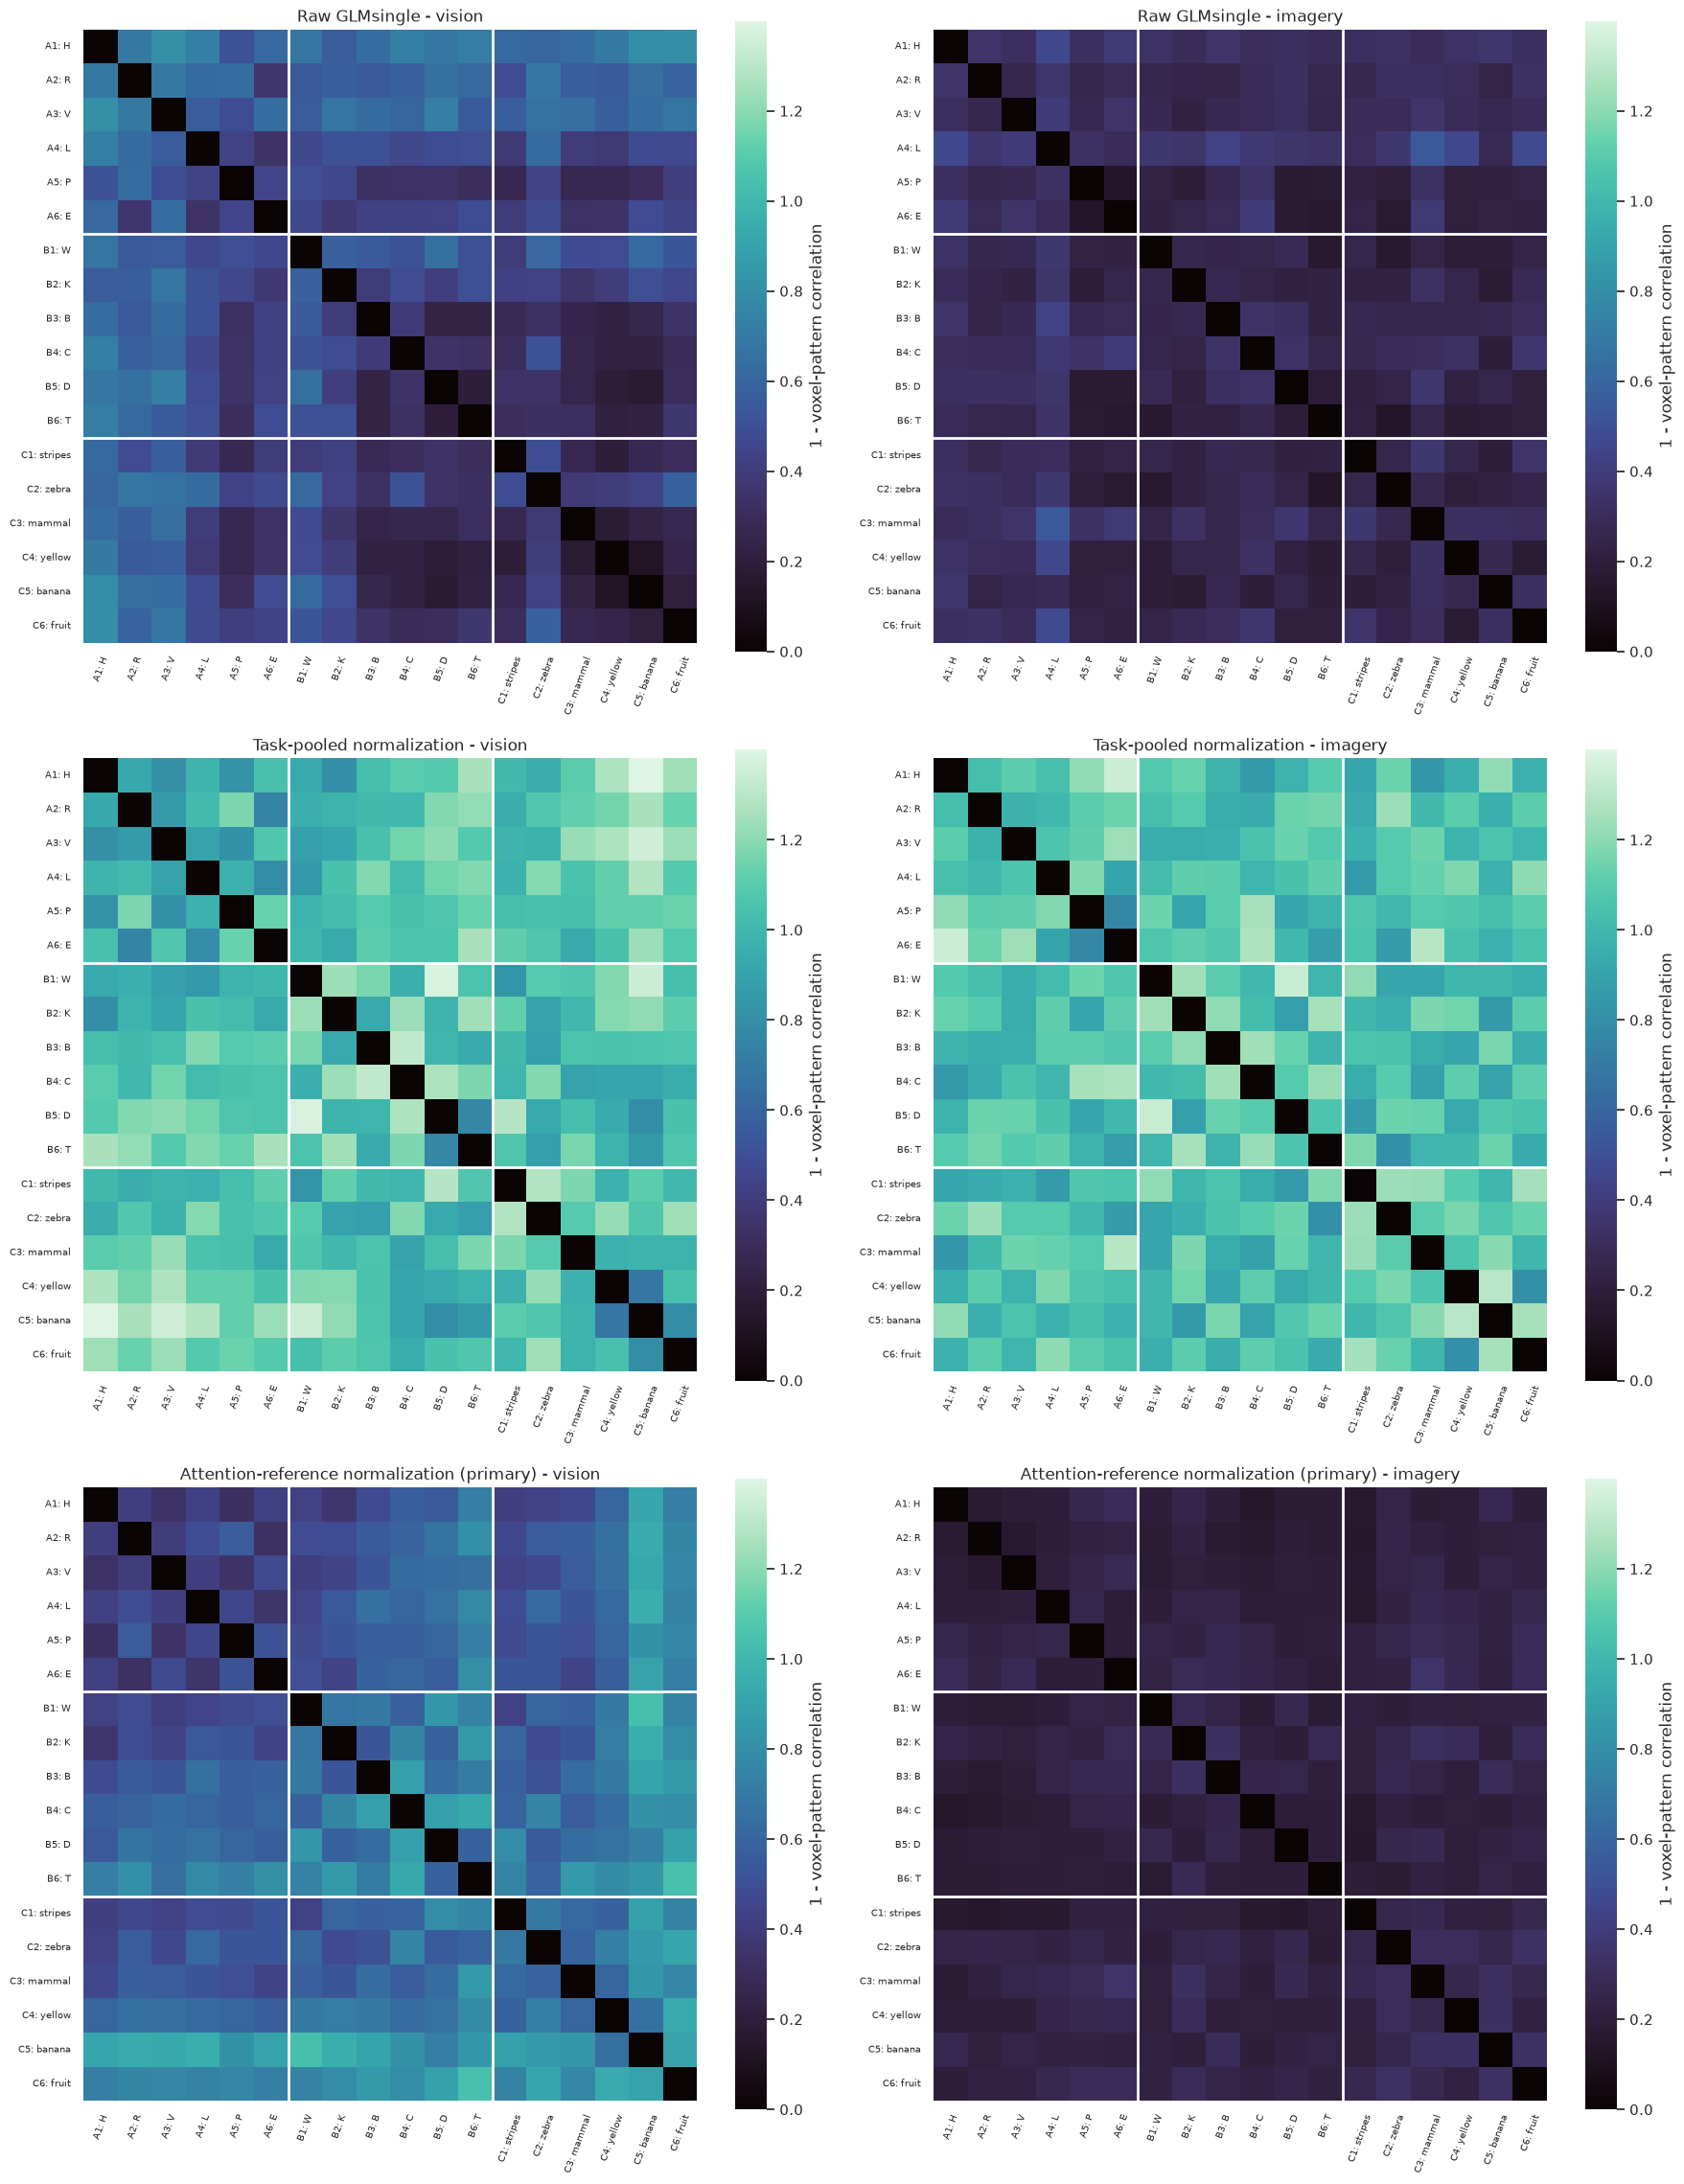

In [6]:
target_labels = [
    (f'{row.stimulus_set}{row.target_number}: {row.target_name}'
     if row.stimulus_set == 'C'
     else f'{row.stimulus_set}{row.target_number}: {row.target_code}')
    for row in target_metadata.itertuples(index=False)
]
pipeline_titles = {
    'raw_glmsingle': 'Raw GLMsingle',
    'task_pooled': 'Task-pooled normalization',
    'attention_reference': 'Attention-reference normalization (primary)',
}

pilot_rdms = [
    correlation_rdms[(PILOT_SUBJECT, 'nsdgeneral', pipeline, task)]
    for pipeline in PIPELINE_ORDER for task in TASK_ORDER
]
pilot_vmax = max(float(rdm.max()) for rdm in pilot_rdms)
fig, axes = plt.subplots(len(PIPELINE_ORDER), len(TASK_ORDER), figsize=(18, 23))
for row_index, pipeline in enumerate(PIPELINE_ORDER):
    for column_index, task in enumerate(TASK_ORDER):
        ax = axes[row_index, column_index]
        sns.heatmap(
            correlation_rdms[(PILOT_SUBJECT, 'nsdgeneral', pipeline, task)],
            square=True, cmap='mako', vmin=0, vmax=pilot_vmax,
            xticklabels=target_labels, yticklabels=target_labels,
            cbar_kws={'label': '1 - voxel-pattern correlation'}, ax=ax,
        )
        add_block_boundaries(ax)
        ax.set_title(f"{pipeline_titles[pipeline]} - {task}")
        ax.tick_params(axis='x', rotation=70, labelsize=7)
        ax.tick_params(axis='y', rotation=0, labelsize=7)
plt.tight_layout()

pilot_block_table = block_summary.query(
    "subject == @PILOT_SUBJECT and roi == 'nsdgeneral'"
).sort_values(['pipeline', 'task', 'set_pair'])
pilot_contrast_table = block_contrasts.query(
    "subject == @PILOT_SUBJECT and roi == 'nsdgeneral'"
).sort_values(['pipeline', 'task'])
display(pilot_block_table)
display(pilot_contrast_table)

## 5. Held-out group and ROI views

The split-triangle atlas below uses the primary attention-reference preprocessing and averages subjects 02-08. Vision occupies the lower triangle and imagery the upper triangle. All ROIs share one color scale.

For each subject, task, ROI, and pipeline, the block statistic is

$$
\Delta_{\mathrm{block}}=\overline D_{\mathrm{between}}-\overline D_{\mathrm{within}}.
$$

Positive values have the visually expected direction: smaller within-set and larger between-set dissimilarity. They remain descriptive because set and run are confounded.

,pipeline,task,roi,n_subjects,mean,median,minimum,maximum
0,attention_reference,imagery,early_visual,7,-0.014972,-0.009655,-0.048999,-0.003591
1,attention_reference,imagery,higher_visual,7,-0.053370,-0.052288,-0.094968,-0.033985
2,attention_reference,imagery,nsdgeneral,7,-0.025434,-0.021363,-0.066071,-0.012164
3,attention_reference,vision,early_visual,7,0.015113,0.014332,-0.017250,0.073494
4,attention_reference,vision,higher_visual,7,-0.046011,-0.056237,-0.078694,-0.013037
5,attention_reference,vision,nsdgeneral,7,0.003680,0.003804,-0.032038,0.045802
6,raw_glmsingle,imagery,early_visual,7,-0.012988,-0.012971,-0.056632,0.014839
7,raw_glmsingle,imagery,higher_visual,7,-0.076657,-0.068956,-0.101255,-0.066192
8,raw_glmsingle,imagery,nsdgeneral,7,-0.017739,-0.022115,-0.064495,0.028044
9,raw_glmsingle,vision,early_visual,7,0.035311,0.042024,0.012792,0.051017


,pipeline,roi,scope,n_subjects,mean,median
0,attention_reference,early_visual,all,7,0.043956,0.072832
1,attention_reference,early_visual,between_set,7,0.008243,-0.066097
2,attention_reference,early_visual,block_residual,7,0.049499,0.040886
3,attention_reference,early_visual,within_set,7,0.101525,0.160738
4,attention_reference,higher_visual,all,7,0.094767,0.033040
5,attention_reference,higher_visual,between_set,7,0.012287,-0.031962
6,attention_reference,higher_visual,block_residual,7,0.055505,0.012188
7,attention_reference,higher_visual,within_set,7,0.113665,0.078524
8,attention_reference,nsdgeneral,all,7,0.067349,0.062409
9,attention_reference,nsdgeneral,between_set,7,0.029036,0.050311


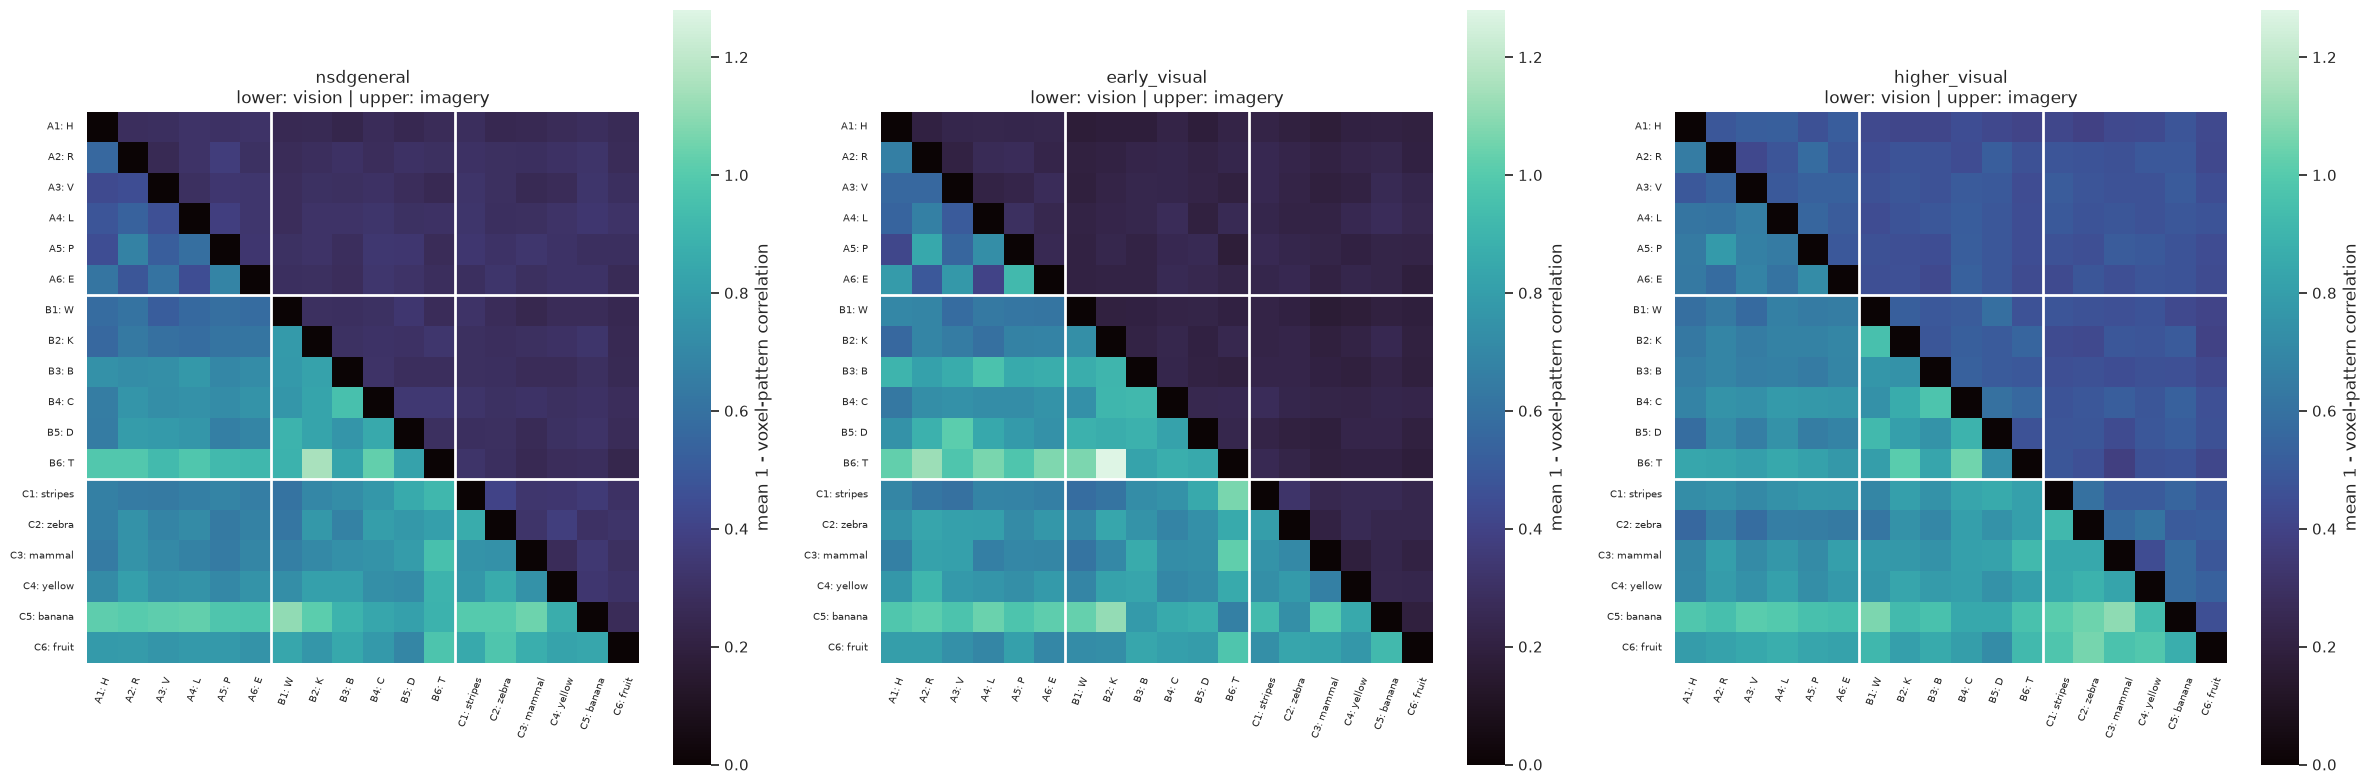

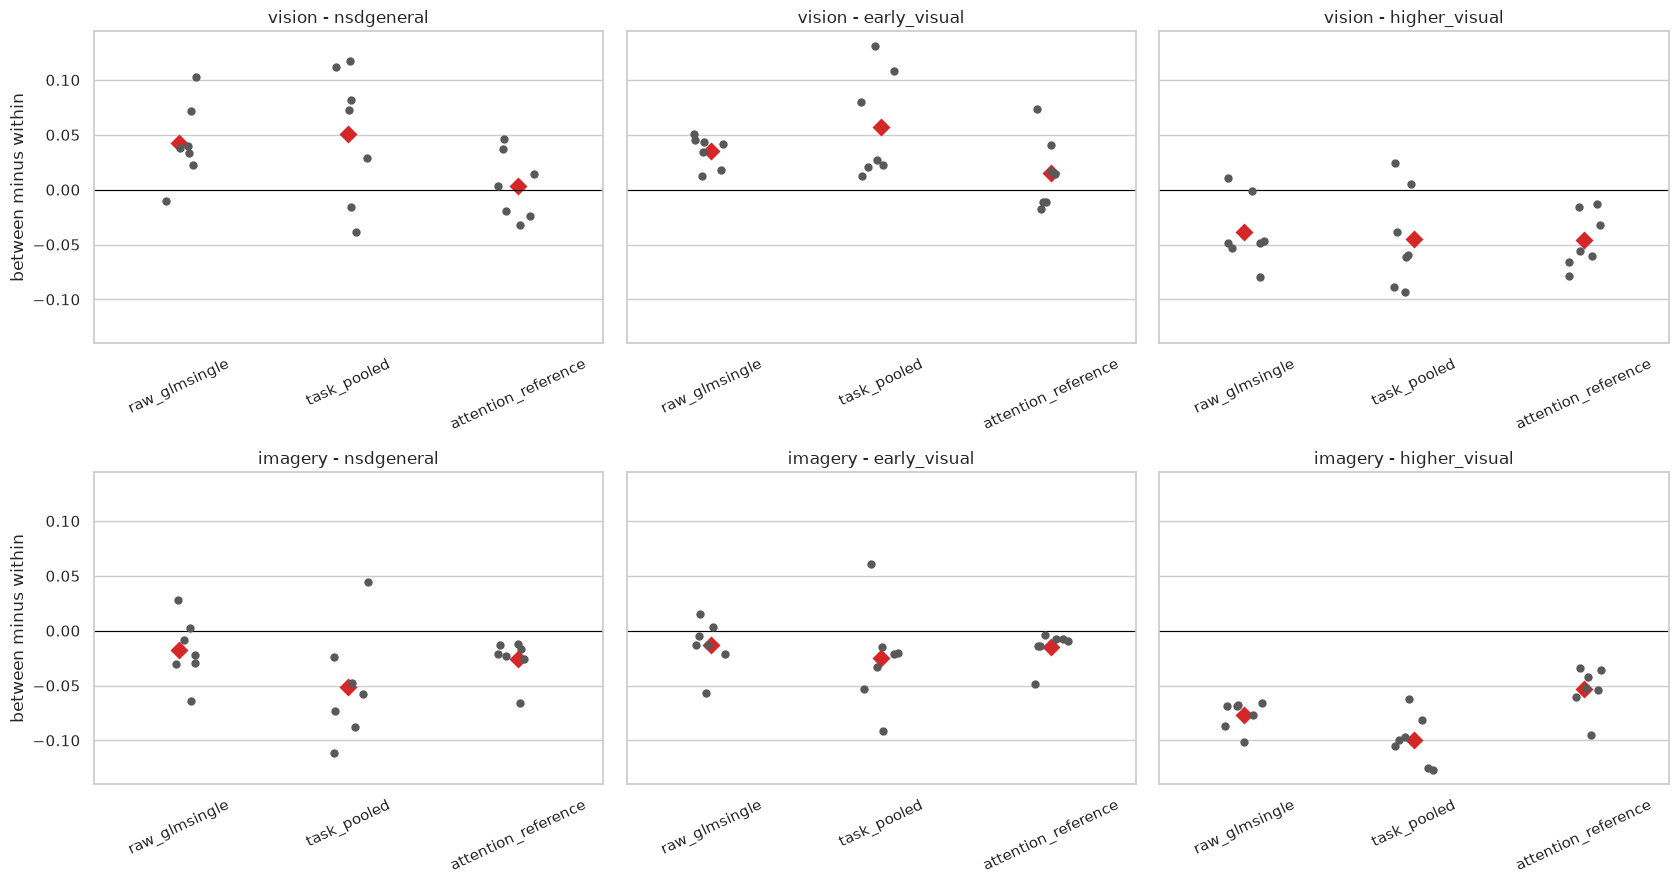

In [7]:
group_primary_rdms = {
    (roi_name, task): np.mean([
        correlation_rdms[(subject, roi_name, PRIMARY_PIPELINE, task)]
        for subject in HELDOUT_SUBJECTS
    ], axis=0)
    for roi_name in ROI_ORDER for task in TASK_ORDER
}
group_vmax = max(float(rdm.max()) for rdm in group_primary_rdms.values())

fig, axes = plt.subplots(1, len(ROI_ORDER), figsize=(24, 8))
for ax, roi_name in zip(axes, ROI_ORDER):
    vision = group_primary_rdms[(roi_name, 'vision')]
    imagery = group_primary_rdms[(roi_name, 'imagery')]
    split_triangle = np.tril(vision, k=-1) + np.triu(imagery, k=1)
    sns.heatmap(
        split_triangle, square=True, cmap='mako', vmin=0, vmax=group_vmax,
        xticklabels=target_labels, yticklabels=target_labels,
        cbar_kws={'label': 'mean 1 - voxel-pattern correlation'}, ax=ax,
    )
    add_block_boundaries(ax)
    ax.set_title(f'{roi_name}\nlower: vision | upper: imagery')
    ax.tick_params(axis='x', rotation=70, labelsize=7)
    ax.tick_params(axis='y', rotation=0, labelsize=7)
plt.tight_layout()

heldout_contrasts = block_contrasts[block_contrasts['phase'].eq('heldout')]
fig, axes = plt.subplots(len(TASK_ORDER), len(ROI_ORDER), figsize=(17, 9), sharey=True)
for row_index, task in enumerate(TASK_ORDER):
    for column_index, roi_name in enumerate(ROI_ORDER):
        ax = axes[row_index, column_index]
        frame = heldout_contrasts[
            heldout_contrasts['task'].eq(task) & heldout_contrasts['roi'].eq(roi_name)
        ]
        sns.stripplot(
            data=frame, x='pipeline', y='delta_between_minus_within',
            order=PIPELINE_ORDER, color='0.35', jitter=.12, size=6, ax=ax,
        )
        sns.pointplot(
            data=frame, x='pipeline', y='delta_between_minus_within',
            order=PIPELINE_ORDER, color='tab:red', errorbar=None,
            markers='D', linestyles='none', ax=ax,
        )
        ax.axhline(0, color='black', linewidth=.8)
        ax.set(
            title=f'{task} - {roi_name}', xlabel='',
            ylabel='between minus within' if column_index == 0 else '',
        )
        ax.tick_params(axis='x', rotation=25)
plt.tight_layout()

group_block_summary = (
    heldout_contrasts
    .groupby(['pipeline', 'task', 'roi'])['delta_between_minus_within']
    .agg(n_subjects='size', mean='mean', median='median', minimum='min', maximum='max')
    .reset_index()
)
group_transfer_summary = (
    vision_imagery_similarity.query("phase == 'heldout'")
    .groupby(['pipeline', 'roi', 'scope'])['rho']
    .agg(n_subjects='size', mean='mean', median='median')
    .reset_index()
)
display(group_block_summary)
display(group_transfer_summary)

## 6. Crossvalidated distances and split reliability

Crossvalidated distances avoid the positive noise bias of ordinary squared distances. They do not solve the experimental confound: vision halves share the same set-specific runs, and imagery run 1/run 2 can retain systematic set effects. Use this atlas as a robustness check, not as proof of categorical organization.

The accompanying reliability table correlates independently estimated correlation RDMs. `within_set` reliability is the most relevant quantity for target-level RSA; `all` can be raised by a reproducible coarse block pattern.

,task,roi,n_subjects,mean,median,minimum,maximum
0,imagery,early_visual,7,0.001284,0.001900,-0.002374,0.003522
1,imagery,higher_visual,7,-0.000722,-0.001174,-0.003148,0.002826
2,imagery,nsdgeneral,7,0.000698,0.000277,-0.001835,0.005311
3,vision,early_visual,7,0.072152,0.076692,0.018829,0.101430
4,vision,higher_visual,7,-0.007356,-0.012619,-0.015700,0.009774
5,vision,nsdgeneral,7,0.031728,0.032858,-0.003278,0.058015


,task,roi,comparison,scope,n_subjects,mean,median
0,imagery,early_visual,run 1/run 2,all,7,0.085322,-0.001354
1,imagery,early_visual,run 1/run 2,between_set,7,0.115089,0.069327
2,imagery,early_visual,run 1/run 2,block_residual,7,0.128919,0.128184
3,imagery,early_visual,run 1/run 2,within_set,7,0.003953,-0.069829
4,imagery,higher_visual,run 1/run 2,all,7,0.186909,0.138290
5,imagery,higher_visual,run 1/run 2,between_set,7,0.145032,0.133756
6,imagery,higher_visual,run 1/run 2,block_residual,7,0.110676,0.071528
7,imagery,higher_visual,run 1/run 2,within_set,7,0.050499,-0.030962
8,imagery,nsdgeneral,run 1/run 2,all,7,0.210740,0.254935
9,imagery,nsdgeneral,run 1/run 2,between_set,7,0.219974,0.187478


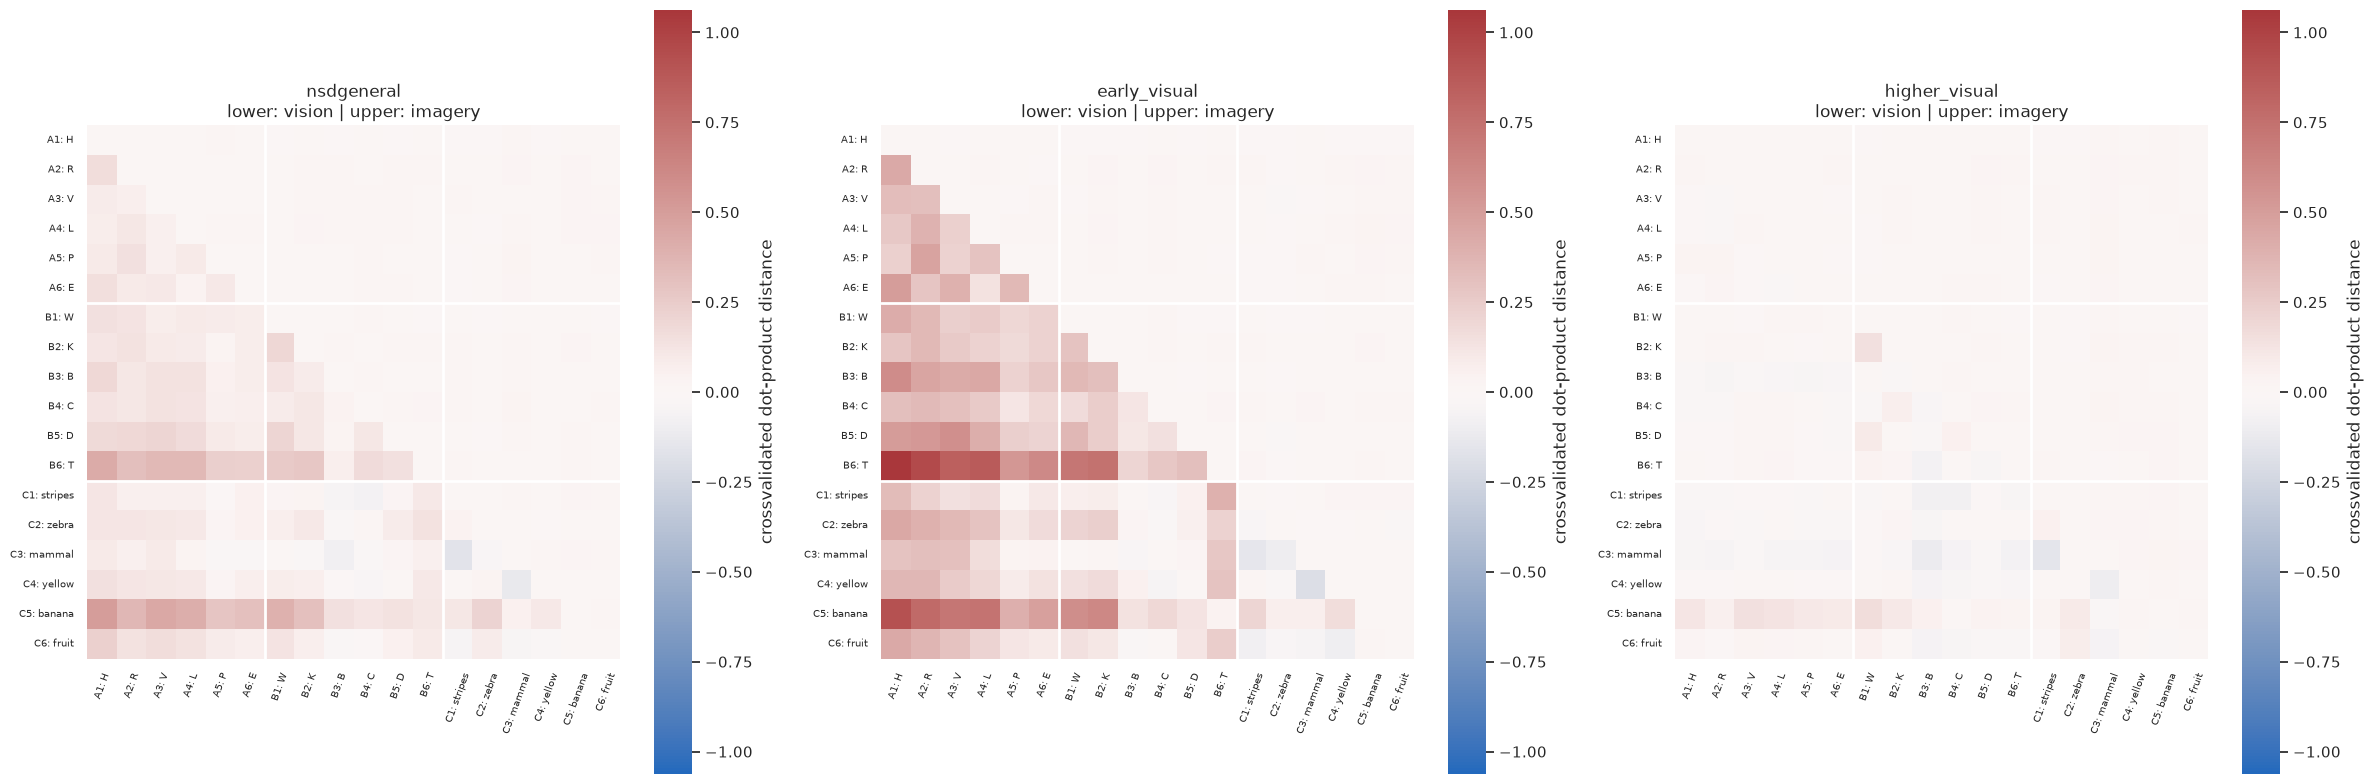

In [8]:
group_cv_rdms = {
    (roi_name, task): np.mean([
        crossvalidated_rdms[(subject, roi_name, task)]
        for subject in HELDOUT_SUBJECTS
    ], axis=0)
    for roi_name in ROI_ORDER for task in TASK_ORDER
}
cv_limit = max(float(np.abs(rdm).max()) for rdm in group_cv_rdms.values())

fig, axes = plt.subplots(1, len(ROI_ORDER), figsize=(24, 8))
for ax, roi_name in zip(axes, ROI_ORDER):
    vision = group_cv_rdms[(roi_name, 'vision')]
    imagery = group_cv_rdms[(roi_name, 'imagery')]
    split_triangle = np.tril(vision, k=-1) + np.triu(imagery, k=1)
    sns.heatmap(
        split_triangle, square=True, cmap='vlag', center=0,
        vmin=-cv_limit, vmax=cv_limit,
        xticklabels=target_labels, yticklabels=target_labels,
        cbar_kws={'label': 'crossvalidated dot-product distance'}, ax=ax,
    )
    add_block_boundaries(ax)
    ax.set_title(f'{roi_name}\nlower: vision | upper: imagery')
    ax.tick_params(axis='x', rotation=70, labelsize=7)
    ax.tick_params(axis='y', rotation=0, labelsize=7)
plt.tight_layout()

group_cv_contrast_summary = (
    crossvalidated_block_contrasts.query("phase == 'heldout'")
    .groupby(['task', 'roi'])['delta_between_minus_within']
    .agg(n_subjects='size', mean='mean', median='median', minimum='min', maximum='max')
    .reset_index()
)
group_reliability_summary = (
    split_reliability.query("phase == 'heldout'")
    .groupby(['task', 'roi', 'comparison', 'scope'])['rho']
    .agg(n_subjects='size', mean='mean', median='median')
    .reset_index()
)
display(group_cv_contrast_summary)
display(group_reliability_summary)

## 7. Interpretation contract

Read the outputs in this order:

1. Check whether the block direction is consistent across raw, task-pooled, and attention-reference RDMs.
2. Check individual-subject values of $\Delta_{\mathrm{block}}$ rather than relying on the group heatmap.
3. Check whether the direction survives in crossvalidated distances.
4. Check within-set split reliability before interpreting fine target geometry.
5. Treat any A/B/C clustering as descriptive set/run organization, not a discovered neural taxonomy.

Notebook 03 retains its original within-set HOG and CLIP analyses. Its mixed 18-target image/text feature appendix is intentionally not recreated here: feature RDMs do not share the neural centering problem, and combining CLIP image embeddings for A/B with text embeddings for C introduces a separate modality gap.

In [9]:
target_metadata.to_csv(OUTPUT_DIR / 'target_metadata.csv', index=False)
block_summary.to_csv(OUTPUT_DIR / 'block_summary_subject_level.csv', index=False)
block_contrasts.to_csv(OUTPUT_DIR / 'block_contrasts_subject_level.csv', index=False)
vision_imagery_similarity.to_csv(
    OUTPUT_DIR / 'vision_imagery_similarity_subject_level.csv', index=False
)
split_reliability.to_csv(OUTPUT_DIR / 'split_reliability_subject_level.csv', index=False)
crossvalidated_block_contrasts.to_csv(
    OUTPUT_DIR / 'crossvalidated_block_contrasts_subject_level.csv', index=False
)
group_block_summary.to_csv(OUTPUT_DIR / 'group_block_summary.csv', index=False)
group_transfer_summary.to_csv(OUTPUT_DIR / 'group_transfer_summary.csv', index=False)
group_cv_contrast_summary.to_csv(
    OUTPUT_DIR / 'group_crossvalidated_block_summary.csv', index=False
)
group_reliability_summary.to_csv(
    OUTPUT_DIR / 'group_split_reliability_summary.csv', index=False
)
np.savez_compressed(
    OUTPUT_DIR / 'correlation_rdms_all_subjects.npz',
    **{
        f'subj{subject:02d}__{roi}__{pipeline}__{task}': rdm
        for (subject, roi, pipeline, task), rdm in correlation_rdms.items()
    },
)
np.savez_compressed(
    OUTPUT_DIR / 'crossvalidated_rdms_all_subjects.npz',
    **{
        f'subj{subject:02d}__{roi}__{task}': rdm
        for (subject, roi, task), rdm in crossvalidated_rdms.items()
    },
)
print('Saved full 18-target sensitivity results to:', OUTPUT_DIR)

Saved full 18-target sensitivity results to: /home/jovyan/NHprojectNSDimagery/outputs/01a_full18_rdm
